In [186]:
'''
playing with anterograde interference'''

'\nplaying with anterograde interference'

In [187]:
# load a matrix from a space-separated file and show it as an image
import sys
sys.path.append('/homes/ar2342/one_more_dir/contextual_frogs/experimental/optim/')
sys.path.append('/homes/ar2342/one_more_dir/contextual_frogs/')
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from optimise_clnn import load_subject_data
from memory_upd_utils import polarity, extract_mem_updates
from model_utils import eval_ys, remove_gen, nans2none, force_model_params
from models import LegacyElboGenerativeModelTop,ElboGenerativeModelTop, ElboGenerativeModelDualRate
from types import SimpleNamespace
import copy
from optimise_clnn import load_subject_data, eval_paradigms
import pickle


In [188]:
def load_adaptation_trace(file_path): 
        df = pd.read_csv(file_path)
        arr = df.Adaptation.to_numpy()
        return arr

In [189]:
LOSS_IS_PER_SAMPLE = False
result_root = '/homes/ar2342/one_more_dir/contextual_frogs/experimental/optim/results/'
coin_bics_path = '/homes/ar2342/one_more_dir/contextual_frogs/experimental/optim/coin_bics.txt'
paradigm_ = {k: 'evoked' if k <= 8 else 'spontaneous' for k in range(1,17)}
coin_bics = np.loadtxt(coin_bics_path)
# exp_datasets = [ load_adaptation_trace(f'/homes/ar2342/frogs_project/data/COIN_data/trial_data_{paradigm_[i]}_recovery_participant{(i-1)%8+1}.csv') for i in range(1,17)]
experimental_data = {}
loss_traces= {}
output_traces= {}
prior_out_batch = {}
posterior_out_batch = {}


In [190]:
'''load model'''

import copy


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
args = SimpleNamespace(model='default',
                       enable_q_scale_tuning=True,
                       assume_opt_output_noise=True, 
                       enable_qlpf=True,
                       enable_ylpf=False,
                       enable_elpf=True,
                       noise_injection_node='x',
                       model_tie_lr_weight_decay=True,
                       bs=2048,
                       zzz_legacy_init=False,
                       enable_output_scale_tuning=True,
                       enable_u_feedback_scale_tuning=True,
                       enable_direct_injection = True,
                       n=2048)

model   =  ElboGenerativeModelTop(device=device, args=args)

In [191]:
def print_params():
    for this_param in model.named_parameters():
        print(this_param)

In [192]:
forced_params = {'log_learning_rate_decay': -20., 
                 'sigma_x': 2.0, 
                 'log_learning_rate': -9.0+np.log(0.1),
                 'sp_weight_decay': -1000.0,
                 'output_scale': 1.0,
                 'u_feedback_scale': 1.0,
                 'sigma_b': 0.1,
                 'q_scale': 1.0,
                 'tauelpf_m1': -1000.0,
                 'tauqlpf_m1': -1000.0,
                 'direct_injection_scale': 0.2}

force_model_params(model, forced_params)
# for name, param in model.named_parameters():
#     if name in forced_params:
#         print(f'Forcing parameter {name} to value {forced_params[name]}')
#         param.data.fill_(forced_params[name])

Forcing parameter log_learning_rate to value -11.302585092994045
Forcing parameter log_learning_rate_decay to value -20.0
Forcing parameter sigma_b to value 0.1
Forcing parameter output_scale to value 1.0
Forcing parameter u_feedback_scale to value 1.0
Forcing parameter sp_weight_decay to value -1000.0
Forcing parameter q_scale to value 1.0
Forcing parameter sigma_x to value 2.0
Forcing parameter tauqlpf_m1 to value -1000.0
Forcing parameter tauelpf_m1 to value -1000.0
Forcing parameter direct_injection_scale to value 0.2


In [193]:
def local_eval_paradigms(model, playlist_file, args,repfac=10):
    with open(playlist_file, 'rb') as f:
        playlist = pickle.load(f)

    model.eval()
    with torch.no_grad():
        outputs = {}
        for paradigm_name,paradigm in playlist.items():
            if 'AB' in paradigm_name or 'savings' in paradigm_name:
                print(f'evaluating paradigm {paradigm_name} with {len(paradigm)} steps')
                #repeat every entry in the paradigm repfac times
                paradigm = [step for step in paradigm for _ in range(repfac)]

                ys = torch.tensor(paradigm, device=next(model.parameters()).device)

                noises = torch.randn((args.bs, len(ys)), device=next(model.parameters()).device) * model.sigma_x  # [bs, t]
                noises = [noises[:, t_idx] for t_idx in range(noises.shape[1])]
                model_setting = args.model
                outputs_ = model.f(args.n,
                                    noises,
                                    ys,  
                                    model_setting,
                                    qs=None,
                                    )
                outputs[paradigm_name] = np.array([z.cpu().numpy().reshape(-1) for z in outputs_]) 
            else:
                print(f'skipping paradigm {paradigm_name} with {len(paradigm)} steps')
    return outputs

In [194]:
paradigm_file='/homes/ar2342/one_more_dir/contextual_frogs/signoffrepertoire4.pkl'
force_model_params(model, forced_params)



Forcing parameter log_learning_rate to value -11.302585092994045
Forcing parameter log_learning_rate_decay to value -20.0
Forcing parameter sigma_b to value 0.1
Forcing parameter output_scale to value 1.0
Forcing parameter u_feedback_scale to value 1.0
Forcing parameter sp_weight_decay to value -1000.0
Forcing parameter q_scale to value 1.0
Forcing parameter sigma_x to value 2.0
Forcing parameter tauqlpf_m1 to value -1000.0
Forcing parameter tauelpf_m1 to value -1000.0
Forcing parameter direct_injection_scale to value 0.2


In [195]:
ooo = local_eval_paradigms(model, paradigm_file, args)


evaluating paradigm savings with 440 steps


evaluating paradigm AB0 with 270 steps
evaluating paradigm AB1 with 283 steps
evaluating paradigm AB2 with 311 steps
evaluating paradigm AB3 with 382 steps
evaluating paradigm AB4 with 500 steps
evaluating paradigm AB5 with 680 steps
skipping paradigm herzfeld,z=0.1$0 with 1125 steps
skipping paradigm herzfeld,z=0.5$0 with 1125 steps
skipping paradigm herzfeld,z=0.9$0 with 1125 steps
skipping paradigm herzfeld,z=0.1$1 with 1125 steps
skipping paradigm herzfeld,z=0.5$1 with 1125 steps
skipping paradigm herzfeld,z=0.9$1 with 1125 steps
skipping paradigm herzfeld,z=0.1$2 with 1125 steps
skipping paradigm herzfeld,z=0.5$2 with 1125 steps
skipping paradigm herzfeld,z=0.9$2 with 1125 steps
skipping paradigm herzfeld,z=0.1$3 with 1125 steps
skipping paradigm herzfeld,z=0.5$3 with 1125 steps
skipping paradigm herzfeld,z=0.9$3 with 1125 steps
skipping paradigm herzfeld,z=0.1$4 with 1125 steps
skipping paradigm herzfeld,z=0.5$4 with 1125 steps
skipping paradigm herzfeld,z=0.9$4 with 1125 steps
s

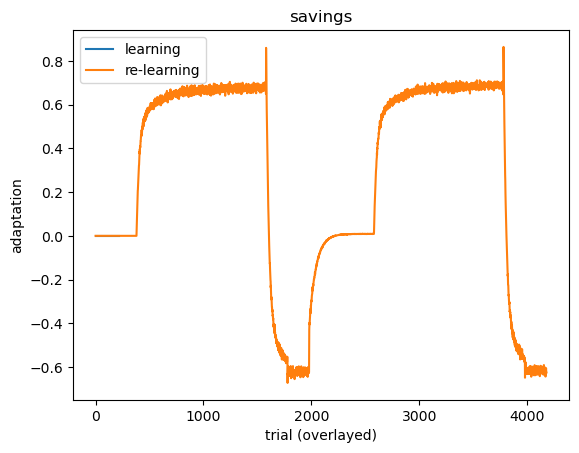

In [196]:
plt.plot(ooo['savings'][:221].mean(axis=1) , label='learning')
plt.plot(ooo['savings'][221:].mean(axis=1), label='re-learning')
plt.title('savings')
plt.xlabel('trial (overlayed)')
plt.ylabel('adaptation')
plt.legend()

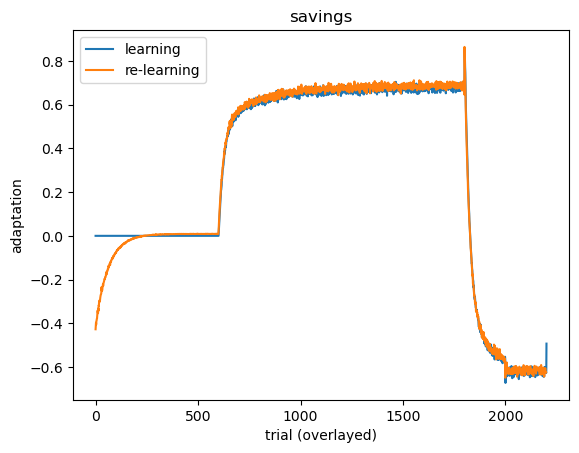

In [197]:
plt.plot(ooo['savings'][:2201].mean(axis=1) , label='learning')
plt.plot(ooo['savings'][2201:].mean(axis=1), label='re-learning')
plt.title('savings')
plt.xlabel('trial (overlayed)')
plt.ylabel('adaptation')
plt.legend()

<Figure size 640x480 with 0 Axes>

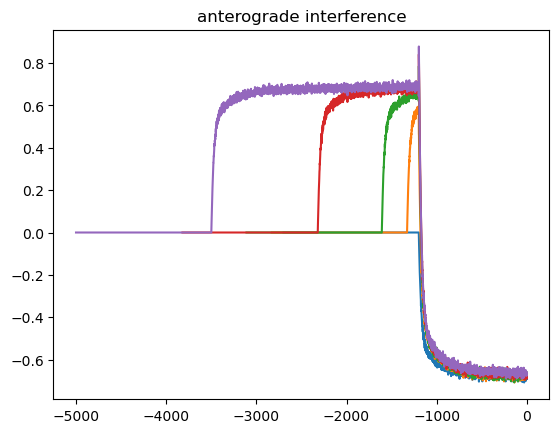

In [198]:
ant_list = [f'AB{i}' for i in range(0,5)]
plt.figure()
plt.figure()
plt.title('anterograde interference')
for ant in ant_list:
    x_data = np.arange(len(ooo[ant].mean(axis=1)))
    plt.plot(x_data-np.max(x_data),ooo[ant].mean(axis=1))

<Figure size 640x480 with 0 Axes>

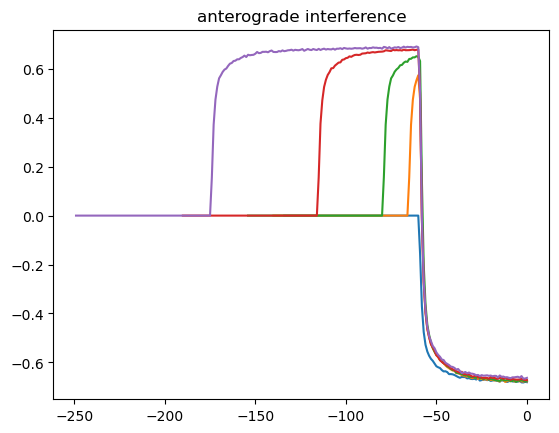

In [199]:
def smooth_trace(trace, window_size=10, collapse=True):
    """Smooth the input trace using a simple moving average."""
    smoothed_trace = np.convolve(trace, np.ones(window_size)/window_size, mode='valid')
    if collapse: #resample accordingly
        factor = window_size
        smoothed_trace = smoothed_trace[::factor]
    return smoothed_trace

ant_list = [f'AB{i}' for i in range(0,5)]
plt.figure()
plt.figure()
plt.title('anterograde interference')
for ant in ant_list:
    ydata = smooth_trace(ooo[ant].mean(axis=1), window_size=20)
    x_data = np.arange(len(ydata))
    plt.plot(x_data-np.max(x_data), ydata)

In [200]:
# deltas_by_super_scenario = {}
# for i, this_data in enumerate([ooo]):
#     # plt.subplot(4,4,i+1)
#     for iz, z in enumerate(ooo.keys()):
#         if 'herzfeld' not in z:
#             continue
#         else:
#             scenario = z
#             super_scenario = z.split('$')[0]
#         deltas = []
#         mm = lambda x: np.mean(x,axis=0)
#         # scenario = f'herzfeld,z={z}'
#         this_result = this_data[scenario].mean(axis=1)
#         pointer = 0
#         for bb in range(25):
#             block_length = len(this_result)//25
#             # pointer += block_length
#             # deltas.append(this_result[pointer-1]-this_result[pointer-3])
#             deltas.append(this_result[pointer+2]-this_result[pointer])
#             pointer += block_length

#         if super_scenario not in deltas_by_super_scenario:
#             deltas_by_super_scenario[super_scenario] = []
#         deltas_by_super_scenario[super_scenario].append(deltas)
#         # plt.plot(deltas,'x',label = f'z={z}')
#         # plt.title('environmental consistency')
#     # plt.legend(loc='upper right')
# plt.figure()
# for k in deltas_by_super_scenario:
#     # plt.plot(np.mean(deltas_by_super_scenario[k],axis=0),label=k)
#     #present with error bars
#     data = np.array(deltas_by_super_scenario[k])
#     mean = np.mean(data,axis=0)
#     std = np.std(data,axis=0)
#     plt.errorbar(np.arange(len(mean)),mean,yerr=std/np.sqrt(data.shape[0]),label=k)

# plt.legend()
# plt.title('environmental consistency')
# # plt.xlim(0,6)

In [201]:
# for ii,k in enumerate(deltas_by_super_scenario):
#     # plt.plot(np.mean(deltas_by_super_scenario[k],axis=0),label=k)
#     #present with error bars
#     data = np.array(deltas_by_super_scenario[k])
#     mean = np.mean(data,axis=0)
#     std = np.std(data,axis=0)
#     plt.errorbar(np.arange(len(mean)),mean,yerr=std/np.sqrt(data.shape[0]),label=k)
#     if ii==0:
#         plt.errorbar(np.arange(len(mean)),-mean,yerr=std/np.sqrt(data.shape[0]), color='tab:blue',alpha=0.3)

# plt.legend()
# plt.title('environmental consistency')